# 🇨🇴 LEGO Through Time: A Brick Journey with Colombian Flavor

<img src="assets/bricks.jpg">

Welcome parcero 👋  

In this notebook, I explore the evolution of LEGO sets from the very first release to modern times.  
I will merge datasets, analyze trends, and visualize everything using **matplotlib**, all while keeping things clean, elegant, and with a little Colombian sazón.

Let’s build this analysis brick by brick 🧱

## 📦 Import & Data Loading

Load all three datasets and get a first glance of the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_colors=pd.read_csv('data/colors.csv')
df_sets=pd.read_csv('data/sets.csv')
df_themes=pd.read_csv('data/themes.csv')

## 🔎 First Look at the Data

Let’s explore what we’re working with — because even in data analysis, first impressions matter.

In [3]:
df_sets.head()
df_sets.info()

<class 'pandas.DataFrame'>
RangeIndex: 26221 entries, 0 to 26220
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   set_num    26221 non-null  str  
 1   name       26221 non-null  str  
 2   year       26221 non-null  int64
 3   theme_id   26221 non-null  int64
 4   num_parts  26221 non-null  int64
 5   img_url    26221 non-null  str  
dtypes: int64(3), str(3)
memory usage: 1.2 MB


In [4]:
df_sets.info()

<class 'pandas.DataFrame'>
RangeIndex: 26221 entries, 0 to 26220
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   set_num    26221 non-null  str  
 1   name       26221 non-null  str  
 2   year       26221 non-null  int64
 3   theme_id   26221 non-null  int64
 4   num_parts  26221 non-null  int64
 5   img_url    26221 non-null  str  
dtypes: int64(3), str(3)
memory usage: 1.2 MB


Structure of the dataset:  
• Set name  
• Year  
• Number of parts  
• Theme ID  

Everything looks listo to start exploring.

## 🎨 Exploring LEGO Colors

LEGO is not just about bricks — it's about color, creatividad, and imagination.

Let’s analyze the color dataset.

In [5]:
unique_colors=df_colors['name'].nunique()
print(f'The number of unique colors produced by the LEGO company is:\n{unique_colors}')

The number of unique colors produced by the LEGO company is:
275


In [6]:
df_transparent=df_colors[df_colors['is_trans'] == True]
transparent_colors=df_transparent['is_trans'].count()

df_opaque=df_colors[df_colors['is_trans'] == False]
opaque_colors=df_opaque['is_trans'].count()

print(f'The number of transparent colors produced by the LEGO company is:\n{transparent_colors}\n\n'
f'The number of opaque colors produced by the LEGO company is:\n{opaque_colors}')

The number of transparent colors produced by the LEGO company is:
45

The number of opaque colors produced by the LEGO company is:
230


Alternative method

In [7]:
counts = df_colors['is_trans'].value_counts()

transparent_colors = counts[True]
opaque_colors = counts[False]

print(f"Transparent: {transparent_colors}")
print(f"Opaque: {opaque_colors}")


Transparent: 45
Opaque: 230


Interesting insight:

We discovered that LEGO has produced a surprisingly high number of unique colors over the years.  
Even more impressive — transparent pieces have their own strong presence.

That’s some serious design creativity.

## 📈 LEGO sets over Time

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.

<img src="assets/lego_themes.png">

A lego set is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.

<img src="assets/lego_sets.png">

Time to answer a big question:

How has LEGO grown over the years?

In [8]:
first_production=df_sets['year'].min()
last_production=df_sets['year'].max()
first_production_id=df_sets['year'].idxmin()
last_production_id=df_sets['year'].idxmax()

print(f"The first set produced was {df_sets['name'].loc[first_production_id]} on {df_sets['year'].loc[first_production_id]}\n"
     f"The first set produced was {df_sets['name'].loc[last_production_id]} on {df_sets['year'].loc[last_production_id]}")

The first set produced was Extra-Large Gift Set (ABB) on 1949
The first set produced was Dinosaur Spidey-Rex vs. Green Goblin on 2026


LEGO sets sold in the year the company started

In [9]:
df_first_production=df_sets[df_sets['year']==first_production]
df_first_production.nunique()

set_num      5
name         5
year         1
theme_id     2
num_parts    5
img_url      5
dtype: int64

The top 5 LEGO sets with the most number of parts. 

In [10]:
df_sorted=df_sets.sort_values('num_parts', ascending=False)
df_sorted.head(5)

,set_num,name,year,theme_id,num_parts,img_url
5125,31203-1,World Map,2021,709,11695,https://cdn.rebrickable.com/media/sets/31203-1...
495,10307-1,Eiffel Tower,2022,721,10001,https://cdn.rebrickable.com/media/sets/10307-1...
24448,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987,https://cdn.rebrickable.com/media/sets/bigbox-...
481,10294-1,Titanic,2021,721,9092,https://cdn.rebrickable.com/media/sets/10294-1...
462,10276-1,Colosseum,2020,721,9036,https://cdn.rebrickable.com/media/sets/10276-1...


### Number of LEGO releases over timeon a line chart using Matplotlib

Note that the .csv file is from late 2020, so to plot the full calendar years, it is require to exclude some data from the chart.

/tmp/ipykernel_221426/4276010890.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16)


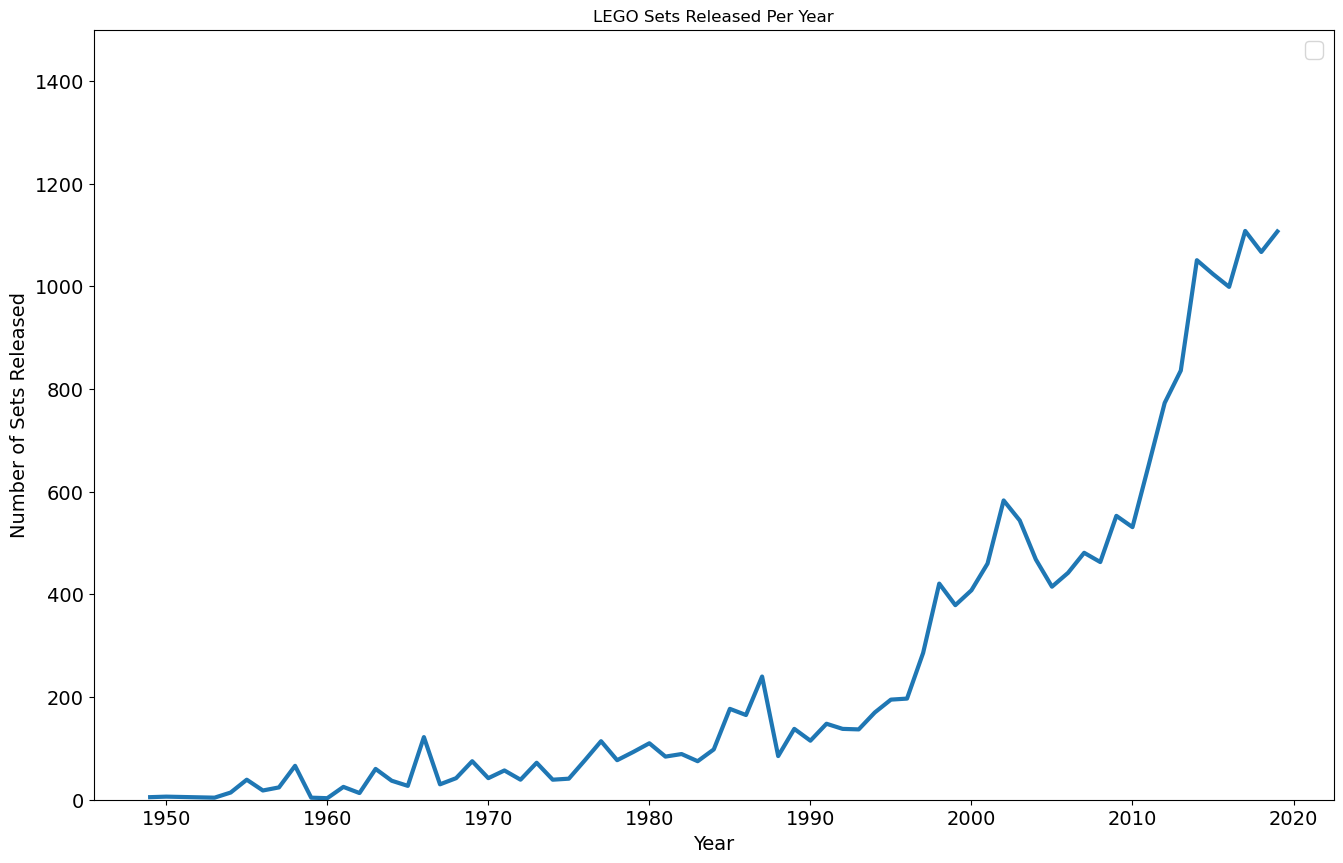

In [11]:
set_counts = df_sets.groupby('year').agg({'name': 'count'})
set_counts = set_counts.reset_index()

sets_filtered = set_counts[(set_counts['year'] <= 2019)]

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Sets Released', fontsize=14)
plt.title("LEGO Sets Released Per Year")
plt.ylim(0, 1500)

plt.plot(sets_filtered ['year'], sets_filtered ['name'], 
             linewidth=3)
 
plt.legend(fontsize=16)

Clearly a strong growth trend, especially after the 1990s.

LEGO went from a small creative toy company to a global empire of imagination.  
From simple bricks to massive collector masterpieces.

That’s exponential growth, mi hermano.

## 📈 LEGO Themes over Time
Let's work out the number of different themes shipped by year.

In [12]:
themes_by_year = df_sets.groupby('year').agg({'theme_id': pd.Series.nunique})
themes_by_year = themes_by_year.reset_index()
themes_by_year.rename(columns={'theme_id':'nr_themes'},inplace=True)

/tmp/ipykernel_221426/946931901.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16)


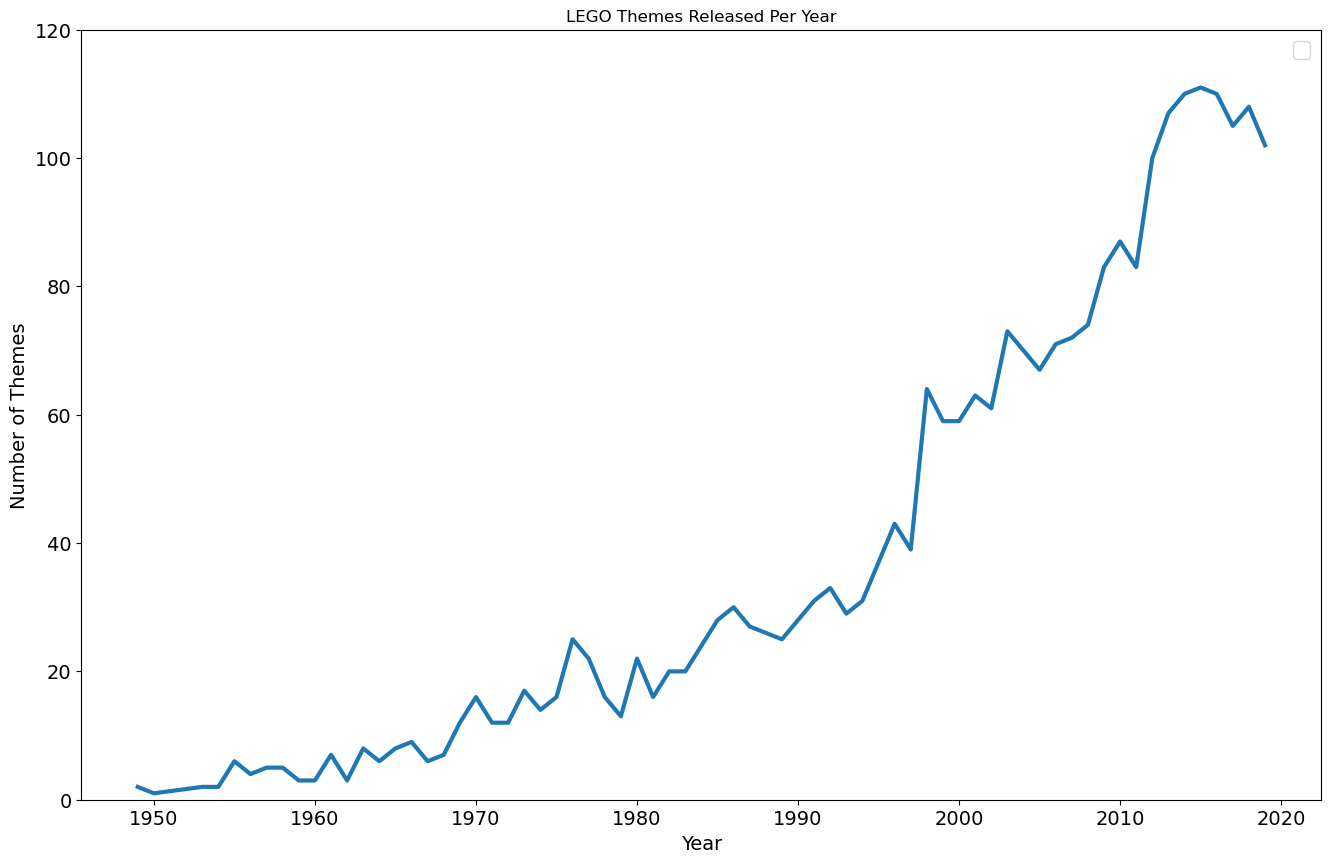

In [13]:
themes_filtered = themes_by_year[(themes_by_year['year'] <= 2019)]

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Themes', fontsize=14)
plt.title("LEGO Themes Released Per Year")
plt.ylim(0, 120)

plt.plot(themes_filtered ['year'], themes_filtered ['nr_themes'], 
             linewidth=3)
 
plt.legend(fontsize=16)

Text(0, 0.5, 'Number of Themes')

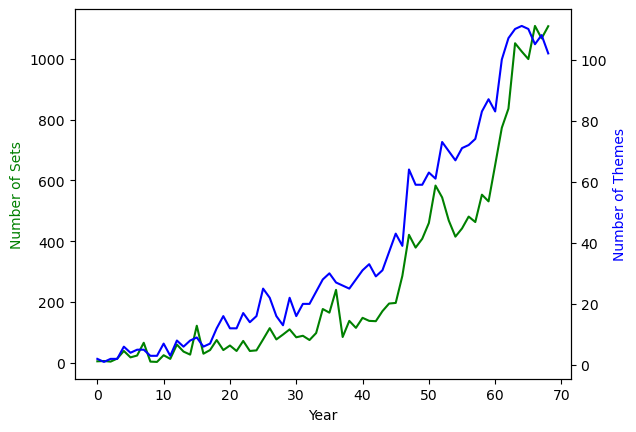

In [14]:
ax1 = plt.gca()
ax2 = ax1.twinx()

# Add styling
ax1.plot(sets_filtered.index, sets_filtered.name, color='g')
ax2.plot(themes_filtered.index, themes_filtered.nr_themes, 'b')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Sets', color='green')
ax2.set_ylabel('Number of Themes', color='blue')

The expansion of themes tells a powerful story.

LEGO didn’t just grow in quantity — it diversified.

Innovation + storytelling = long-term success.

## 🧱 Average Number of Parts Per Set

Are LEGO sets getting more complex over time?  
Let’s investigate.

/tmp/ipykernel_221426/861103325.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16)


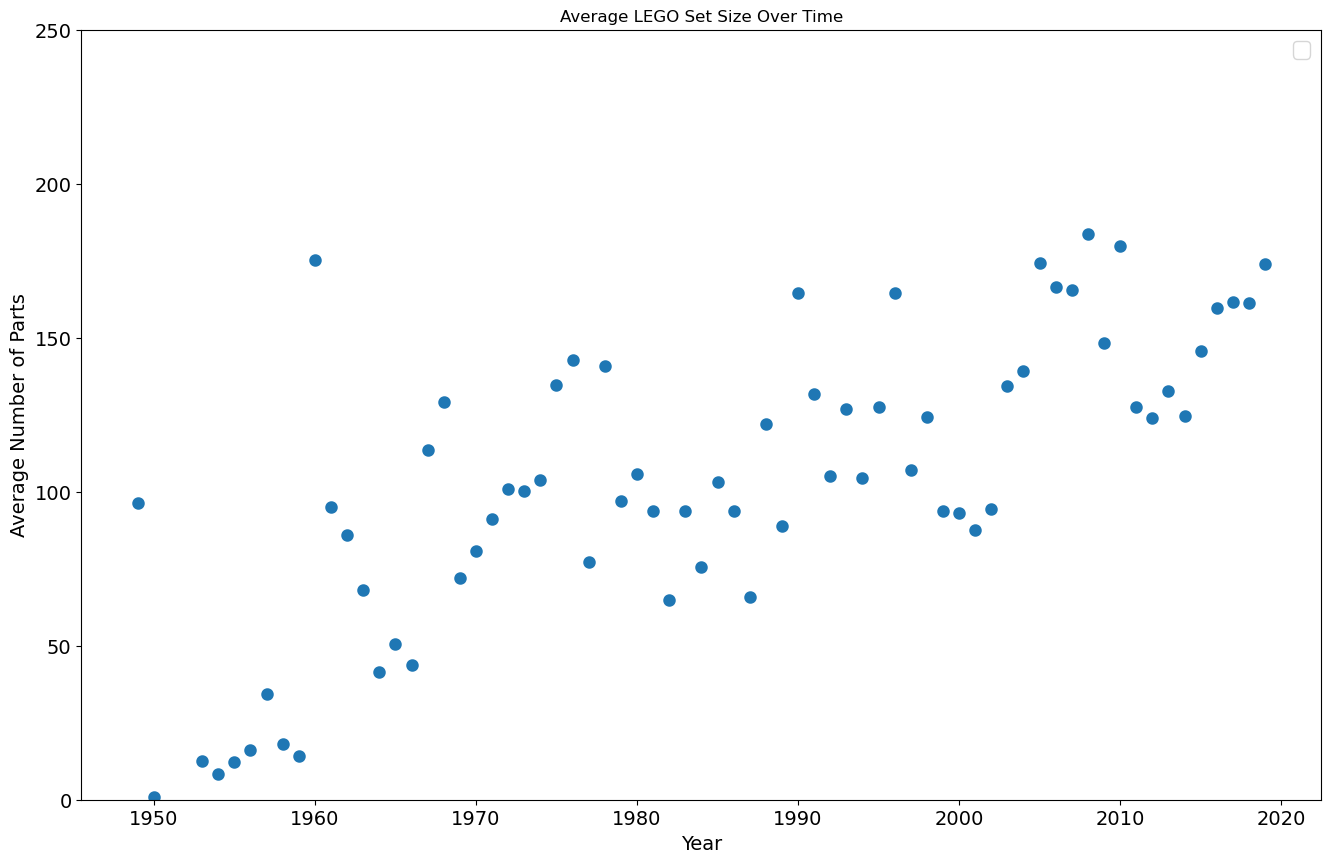

In [15]:
parts_per_set = df_sets.groupby('year').agg({'num_parts': pd.Series.mean})
parts_per_set = parts_per_set.reset_index()
parts_filtered = parts_per_set[(parts_per_set['year'] <= 2019)]

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Number of Parts', fontsize=14)
plt.title("Average LEGO Set Size Over Time")
plt.ylim(0, 250)

plt.scatter(parts_filtered['year'], parts_filtered ['num_parts'], 
             linewidth=3)
 
plt.legend(fontsize=16)

The trend shows that modern LEGO sets are significantly more complex.

Early LEGO sets were simple and minimal.  
Today? Massive builds with thousands of pieces.

## 🎭 LEGO Themes Expansion

Themes are where storytelling happens.

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv. 

<img src="assets/rebrickable_schema.png">

Let’s merge the datasets to see how themes evolved.

In [16]:
set_theme_count = df_sets["theme_id"].value_counts()
set_theme_count[:5]

theme_id
158    1018
503     811
777     769
739     694
494     666
Name: count, dtype: int64

In [17]:
set_theme_count = pd.DataFrame({'id':set_theme_count.index, 
                                'set_count':set_theme_count.values})


merged_df = pd.merge(set_theme_count, df_themes, on='id')
merged_df[:3]

,id,set_count,name,parent_id
0,158,1018,Star Wars,NaN
1,503,811,Key Chain,501.0
2,777,769,"Bags, Totes, & Luggage",501.0


<BarContainer object of 10 artists>

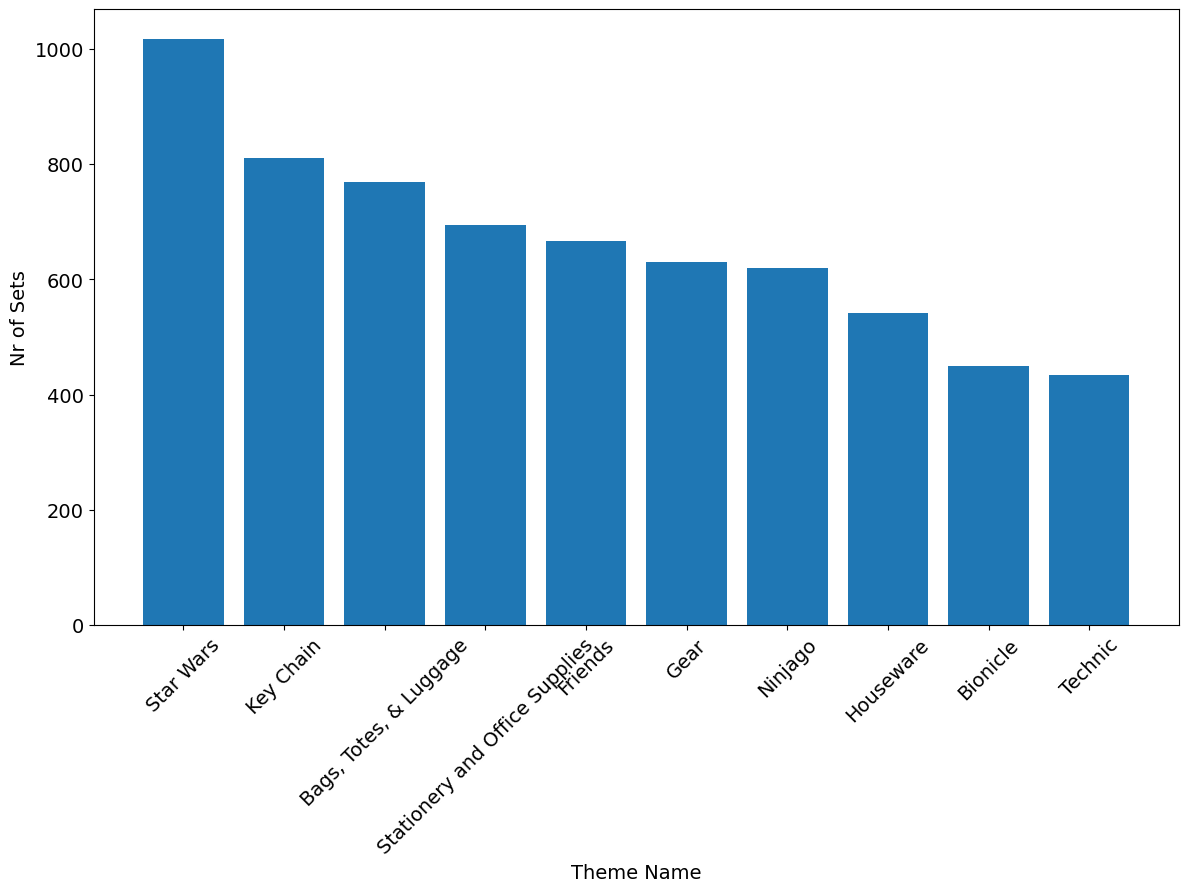

In [18]:
plt.figure(figsize=(14,8))
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.ylabel('Nr of Sets', fontsize=14)
plt.xlabel('Theme Name', fontsize=14)

plt.bar(merged_df.name[:10], merged_df.set_count[:10])